## Data

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

with open("model.txt") as f:
    model_name = f.readline().strip()

dynamo = pd.read_csv(f"{model_name}-Dynamo.csv").drop(columns=["Unnamed: 0", "acceleration"])
script = pd.read_csv(f"{model_name}-Script.csv").drop(columns=["Unnamed: 0", "acceleration"])
tfxla = pd.read_csv(f"{model_name}-TF.csv").drop(columns=["Unnamed: 0", "acceleration"])

dynamo_nabla = dynamo[dynamo.item == "Nabla"]
script_nabla = script[script.item == "Nabla"]
tfxla_nabla = tfxla[tfxla.item == "Nabla"]

nabla = dynamo_nabla.copy()
nabla.time = (dynamo_nabla.time + script_nabla.time + tfxla_nabla.time) / 3
nabla

dynamo_nabla = dynamo[dynamo.item == "Nabla Optim"]
script_nabla = script[script.item == "Nabla Optim"]
tfxla_nabla = tfxla[tfxla.item == "Nabla Optim"]

nabla_optim = dynamo_nabla.copy()
nabla_optim.time = (dynamo_nabla.time + script_nabla.time + tfxla_nabla.time) / 3
nabla_optim

dynamo = dynamo[(dynamo.item != "Nabla") & (dynamo.item != "Nabla Optim")]
script = script[(script.item != "Nabla") & (script.item != "Nabla Optim")]
tfxla = tfxla[(tfxla.item != "Nabla") & (tfxla.item != "Nabla Optim")]

df = pd.concat([nabla, dynamo, script, tfxla, nabla_optim])
passes = ["Forward", "Backward", "Full"]

for i, p in enumerate(passes):
    sub = df[df["pass"] == p]
    sub["acceleration"] = float(sub[sub.item == "Nabla"].time) / sub.time
    passes[i] = sub
    
df = pd.concat(passes)
df.to_csv("Baseline.csv")

## Visualization

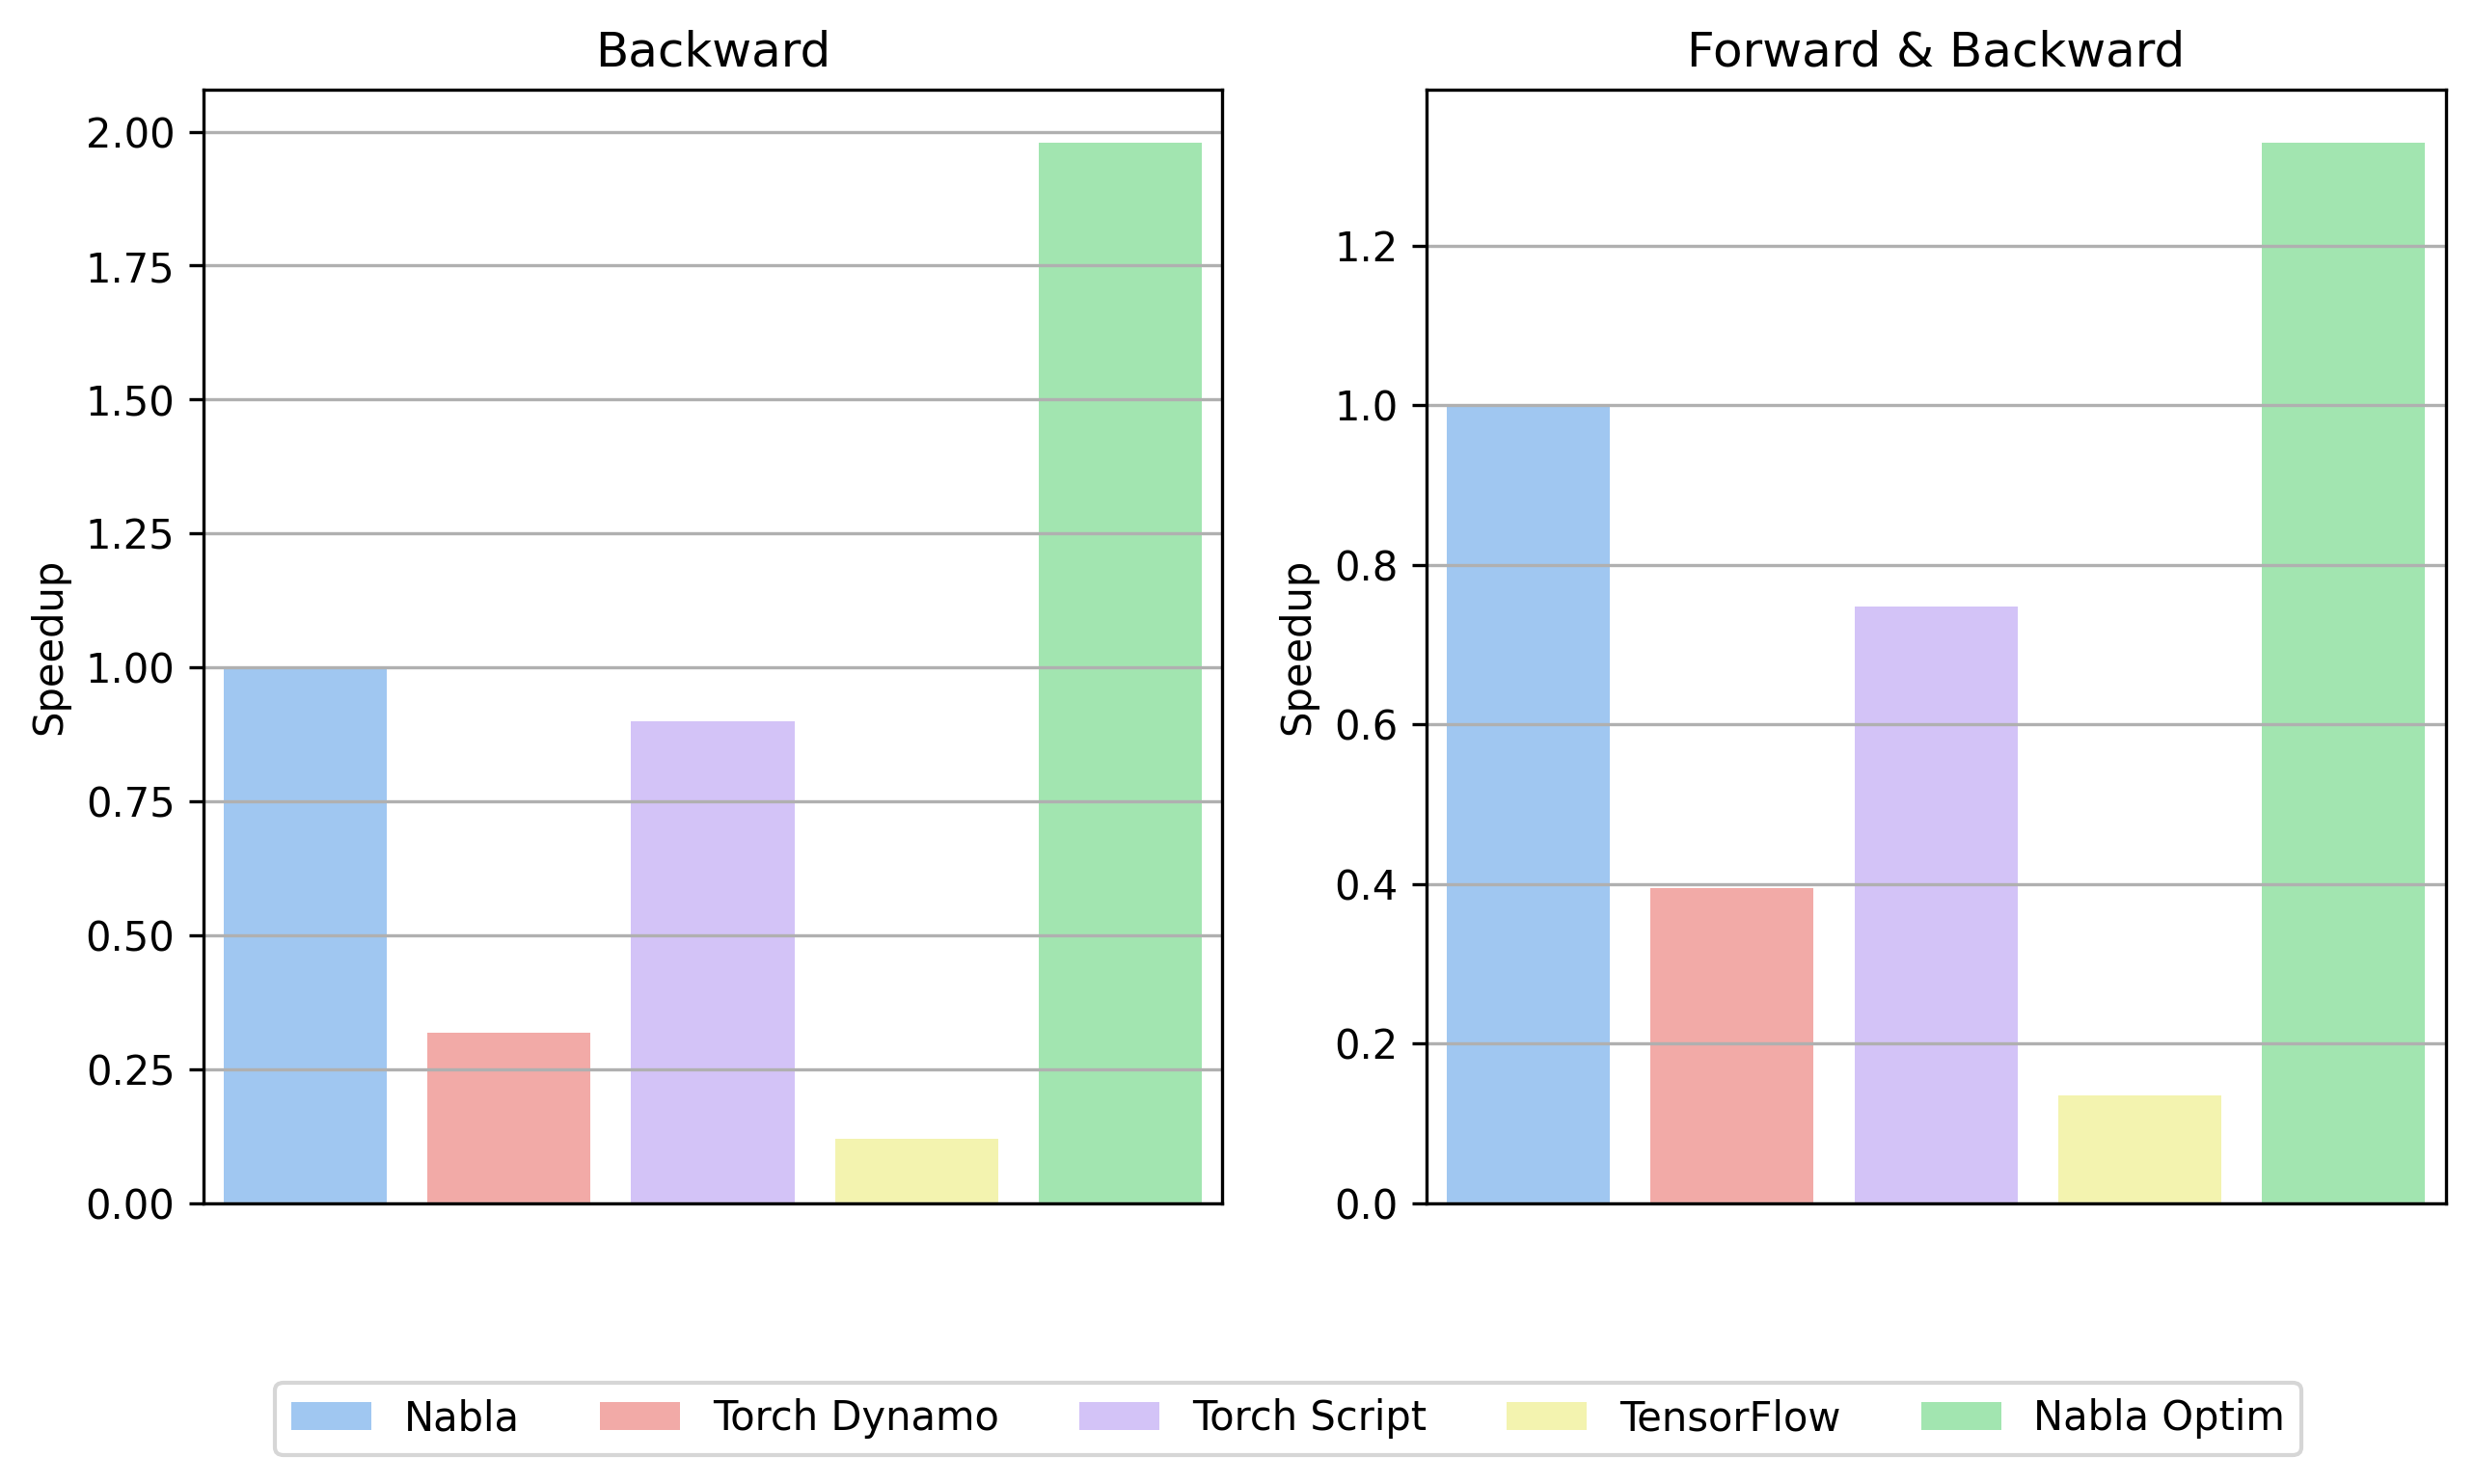

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 300
plt.style.use("seaborn-v0_8-pastel")

palette = sns.color_palette()
palette = [palette[0], *palette[2:5], palette[1], palette[5]]

fig, (left, right) = plt.subplots(1, 2, figsize=(10, 5))

b = sns.barplot(df[df["pass"] == "Backward"], x="item", y="acceleration", hue="item", dodge=False, ax=left, palette=palette)
f = sns.barplot(df[df["pass"] == "Full"], x="item", y="acceleration", hue="item", dodge=False, ax=right, palette=palette)

for sub in [b, f]:
    sub.set_xlabel(None)
    sub.set_xticks([])
    sub.set_ylabel("Speedup")
    sub.yaxis.grid(True)
    sub.legend().set_visible(False)
    
b.set_title("Backward")
f.set_title("Forward & Backward")
    
fig.legend(*sub.get_legend_handles_labels(), loc="upper center", ncols=5, bbox_to_anchor=(0.5, 0))